## Tutoria2 : Inferring the observed data to learn stochastic dynamic.

The dyngpt package contains several pre-trained state transition networks. By providing the model name and associated observed data, one can learn the stochastic dynamic from the static observed data. We demonstrate the code execution process using the autoregulatory feedback loop model model as an illustrative example.

The system state is $s={{\left( {{s}_{\text{OFF}}},{{s}_{\text{ON}}},{{s}_{\text{P}}} \right)}^{\text{T}}}\in {{\left\{ 0,1 \right\}}^{2}}\times \mathbb{N}$ where ${{s}_{\text{OFF}}}$ and ${{s}_{\text{ON}}}$ indicate whether the promoter is in the inactive or active state, and ${{s}_{\text{P}}}$ is the number of protein molecules.  Five state transition vectors characterize promoter binding/unbinding events, protein production, and degradation:
$$\Delta _{i}^{\left( 1 \right)}=-{{\delta }_{i,\text{OFF}}}+{{\delta }_{i,\text{ON}}}-{{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 2 \right)}={{\delta }_{i,\text{OFF}}}-{{\delta }_{i,\text{ON}}}+{{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 3 \right)}={{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 4 \right)}={{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 5 \right)}=-{{\delta }_{i,\text{P}}},$$
where $ i \in \left\{ \text{OFF},\text{ON},\text{P} \right\}$ and ${{\delta }_{i,j}}$ is the Kronecker delta. The corresponding occurrence propensities depend on the current promoter state and protein count: 
$${{\lambda }_{1}}\left( s \right)={{k}_{\text{on}}}{{s}_{\text{OFF}}}{{s}_{\text{P}}},{{\lambda }_{2}}\left( s \right)={{k}_{\text{off}}}{{s}_{\text{ON}}},{{\lambda }_{3}}\left( s \right)=k_{\text{syn}}^{\text{on}}{{s}_{\text{ON}}},{{\lambda }_{4}}\left( s \right)=k_{s\text{yn}}^{\text{off}}{{s}_{\text{OFF}}},{{\lambda }_{5}}\left( s \right)={{k}_{\deg }}{{s}_{\text{P}}}.$$ 
In this STN, ${{\theta }_{\text{Dyn}}}=\left\{ {{k}_{\text{on}}},{{k}_{\text{off}}},k_{\text{syn}}^{\text{on}},k_{s\text{yn}}^{\text{off}},{{k}_{\deg }} \right\}$.

### Load package

In [1]:
import os
import torch
import json
import numpy as np
import pandas as pd
import math
# import dyngpt
import sys 
root_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/"
sys.path.append(root_path)
os.chdir(root_path)

from dyngpt.inferrer import inferring_observed_data
from dyngpt.dynmodels.afl import get_afl_model_config
from dyngpt.utils.util import load_promt_prob
from dyngpt.plotting._plotting import plot_afl_inference_data_burst_distribution


/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT


### Load observed data

In [2]:
root_dir = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT_pre/"
model_name = "afl"
observed_data_path =  root_dir + "data/DMSO_scRNA_counts.csv" # load scRNA-seq data
observed_data = pd.read_csv(observed_data_path,index_col=0)
row_means = observed_data.mean(axis=1)
filtered_observed_data  = observed_data[(row_means >= 1) & (row_means <= 100)]
filtered_observed_data = filtered_observed_data.clip(upper=148) #(n,m) n is the group number, m is the sample number, the species number is 1.
print("the filtered_observed_data shape is",filtered_observed_data.shape)

the filtered_observed_data shape is (10, 812)


### Infer the observed data

In [3]:
figure_dir = root_dir + "figure/{}/".format(model_name)
result_dir = root_dir + "result/{}/".format(model_name)
args = get_afl_model_config()
args.batch_size = math.ceil(filtered_observed_data.shape[1] / 1000) * 1000
args.inference_lr = 0.001
args.loss_type="Hellinger" # Hellinger or Likelihood
sample_number = 5
iter_epoch= 100
random_r0_number = 3
observed_datas, nn_sample_datas, es_params, es_loss, es_param = inferring_observed_data(filtered_observed_data,args,sample_number=sample_number,iter_epoch=iter_epoch,random_r0_number=random_r0_number,
                        model_name = model_name, figure_dir="",result_dir=result_dir)

number of parameters: 0.06M
the index is 0,the batch size is 106
best param kl value is  0.11581549002156527
Allocated GPU memory: 0.0021 GB
the index is 1,the batch size is 38
best param kl value is  0.06047858001399279
Allocated GPU memory: 0.0021 GB
the index is 2,the batch size is 40
best param kl value is  0.04295296038002779
Allocated GPU memory: 0.0021 GB
the index is 3,the batch size is 20
best param kl value is  0.007637709306014377
Allocated GPU memory: 0.0021 GB
the index is 4,the batch size is 14
best param kl value is  0.005141171996676583
Allocated GPU memory: 0.0021 GB


### Visualize result


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to Helvetica.
findfont: Font family ['Arial'] not found. Falling back to Helvetica.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

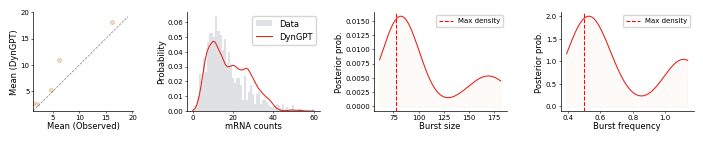

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

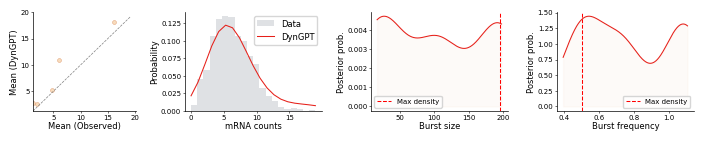

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

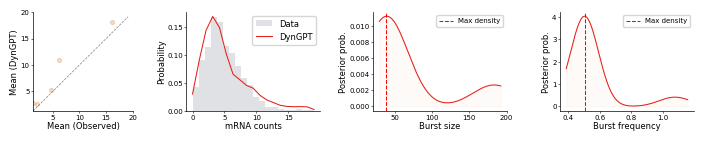

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

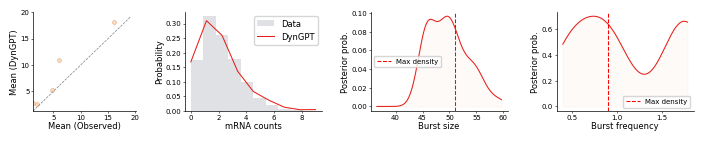

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

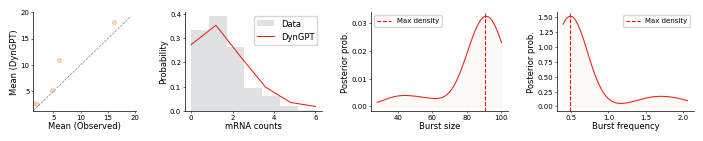

In [4]:
from dyngpt.plotting._plotting import plot_afl_inference_data_burst_distribution
plot_afl_inference_data_burst_distribution(observed_datas, nn_sample_datas, es_params, es_loss, es_param,figure_dir=figure_dir, model_name = model_name,show_flag=True)

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


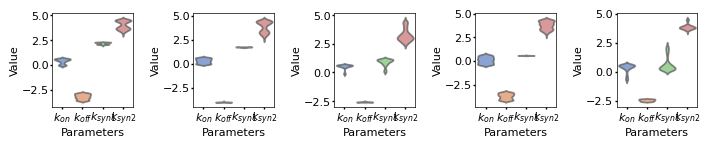

In [15]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
def plot_violin(ax,data,true_values,color="#C9CACA",edgecolor="#009ACE"):
#     sns.violinplot(data=data, ax=ax,inner=None,color=color,edgecolor=edgecolor)
    sns.violinplot(data=data, ax=ax,inner=None, palette='muted', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=8)
    line_length = len(true_values)
    line_length = 3
    for j, true_value in enumerate(true_values):
        if j==0:
            ax.axhline(y=true_value, xmin=j/line_length, xmax=(j+1)/line_length, color='grey', linestyle='--',label='True value',linewidth=linewidth)
        else:
            ax.axhline(y=true_value, xmin=j/line_length, xmax=(j+1)/line_length, color='grey', linestyle='--',linewidth=linewidth)

    set_font_label(ax, "Parameters", "Value")
#     ax.legend(loc='upper left', prop={'size': 6},bbox_to_anchor=(0, 0.9, 0.1, 0.1))

def weighted_sample(values,weights):
    kde = gaussian_kde(values, weights=weights)
    values = np.linspace(min(values)*0.8, max(values), 1000)
    probabilities = kde(values)
    probabilities /= probabilities.sum() 
    sampled_values = np.random.choice(values, size=1500, p=probabilities)
    return sampled_values
def set_font_label(ax,x_label,y_label,font_size=8,font_name='Arial',labelsize=8,tick_width=1): # 6.5
    ax.set_xlabel(x_label, fontsize=font_size, fontname=font_name,labelpad=1)
    ax.set_ylabel(y_label, fontsize=font_size, fontname=font_name,labelpad=1)
    ax.tick_params(axis='both', which='major', labelsize=labelsize, length=1.6, pad=1,width=tick_width)
    ax.tick_params(axis='both', which='minor', labelsize=labelsize, length=1.6,pad=1,width=tick_width)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    return ax

scatter_color = "#C1E8FB"  #009ACE
width_mm = 183
width_inch = width_mm * 0.0393701
height_inch = width_inch*0.22
fig_cols = 5
fig, axes = plt.subplots(nrows=1, ncols=fig_cols, figsize=(width_inch, height_inch))
for param_index in range(5):
    data_col_names = ["$k_{on}$","$k_{off}$","$k_{syn1}$","$k_{syn2}$"]
    sampled_values_li = [weighted_sample(es_params[param_index][:,param_comp_index],1/es_loss[param_index])  for param_comp_index in range(len(data_col_names))]
    true_values = []
    data = pd.DataFrame(np.array(sampled_values_li).T,columns=data_col_names)
    # Create grid of subplots
    plot_violin(axes[param_index],data,true_values,edgecolor = scatter_color)
    plt.tight_layout()